In [1]:
import least_entropy as le
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import os

0it [00:00, ?it/s]

10000it [00:06, 1468.50it/s]


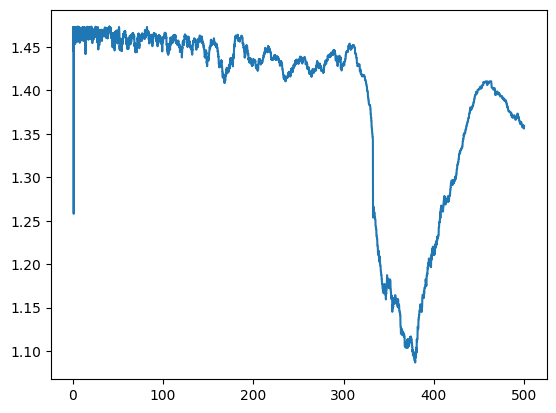

El período que minimiza la entropía es: 379.38449844984495
Entropía mínima: 1.0869067256376683


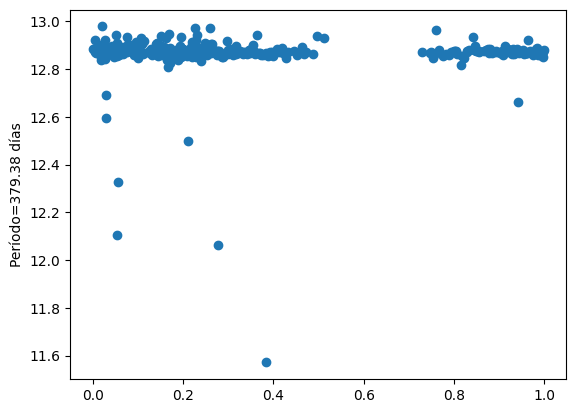

In [ ]:
test_data = pd.read_csv("data/bul5I/2.dat", sep=" ", lineterminator="\n",names=("t","u","inc_u"))

best_period, min_entropy, final_phases = le.find_best_period(test_data, plot_entropies=True, p0=0.4, p1=500, np=10000)

print(f"El período que minimiza la entropía es: {best_period}")
print(f"Entropía mínima: {min_entropy}")

plt.scatter(final_phases,test_data["u"])
plt.ylabel(f"Período={best_period:.2f} días")
plt.show()

In [2]:
def procesar_archivos_bul5I(carpeta="data/bul5I", N=10, p0=0.4, p1=500, p_num=10000, plot_individual=False):
    """
    Procesa los primeros N archivos de la carpeta bul5I
    
    Parámetros:
    -----------
    carpeta : str
        Ruta a la carpeta con los archivos .dat
    N : int
        Número de archivos a procesar
    p0, p1, np : parámetros para find_best_period
    plot_individual : bool
        Si True, muestra la curva de luz de cada estrella
    """
    
    # Obtener lista de archivos .dat y ordenarlos numéricamente
    archivos = [f for f in os.listdir(carpeta) if f.endswith('.dat')]
    archivos.sort(key=lambda x: int(x.split('.')[0]))  # Ordena por número
    
    # Limitar a los primeros N
    archivos = archivos[:N]
    
    print(f"Procesando {len(archivos)} archivos de {carpeta}")
    
    # Lista para guardar resultados
    resultados = []
    
    for archivo in tqdm(archivos, desc="Procesando estrellas"):
        try:
            # Cargar datos
            ruta_completa = os.path.join(carpeta, archivo)
            test_data = pd.read_csv(ruta_completa, sep=" ", lineterminator="\n", 
                                    names=("t", "u", "inc_u"))
            
            # Encontrar período
            best_period, min_entropy, final_phases = le.find_best_period(
                test_data, plot_entropies=False, p0=p0, p1=p1, p_num=p_num
            )
            
            # Guardar resultado
            resultados.append({
                'archivo': archivo,
                'id': archivo.replace('.dat', ''),
                'best_period': best_period,
                'min_entropy': min_entropy,
                'n_puntos': len(test_data)
            })
            
            # Plot individual si se solicita
            if plot_individual:
                plt.figure(figsize=(8, 4))
                plt.scatter(final_phases, test_data["u"], s=5, alpha=0.7)
                plt.xlabel('Fase')
                plt.ylabel('Magnitud')
                plt.title(f'Estrella {archivo} - Período = {best_period:.4f} días')
                plt.gca().invert_yaxis()  # Para magnitudes
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
        except Exception as e:
            print(f"Error procesando {archivo}: {e}")
            resultados.append({
                'archivo': archivo,
                'id': archivo.replace('.dat', ''),
                'best_period': None,
                'min_entropy': None,
                'n_puntos': None,
                'error': str(e)
            })
    
    # Crear DataFrame con resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Mostrar resumen
    print("\n" + "="*60)
    print("RESUMEN DE RESULTADOS")
    print("="*60)
    for idx, row in df_resultados.iterrows():
        if row['best_period'] is not None:
            print(f"{row['id']}: Período = {row['best_period']:.6f} días, "
                  f"Entropía = {row['min_entropy']:.4f}, Puntos = {row['n_puntos']}")
        else:
            print(f"{row['id']}: ERROR - {row.get('error', 'Desconocido')}")
    
    return df_resultados

Procesando 5 archivos de data/bul5I


Procesando estrellas:   0%|          | 0/5 [00:00<?, ?it/s]

5000it [00:04, 1150.89it/s]


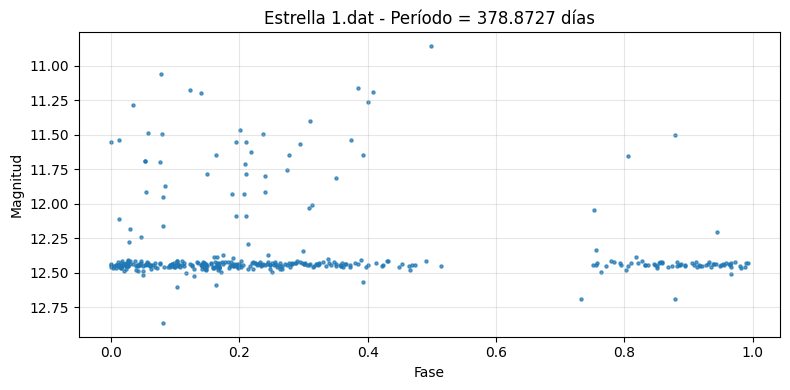

5000it [00:04, 1109.86it/s]██        | 1/5 [00:04<00:18,  4.72s/it]


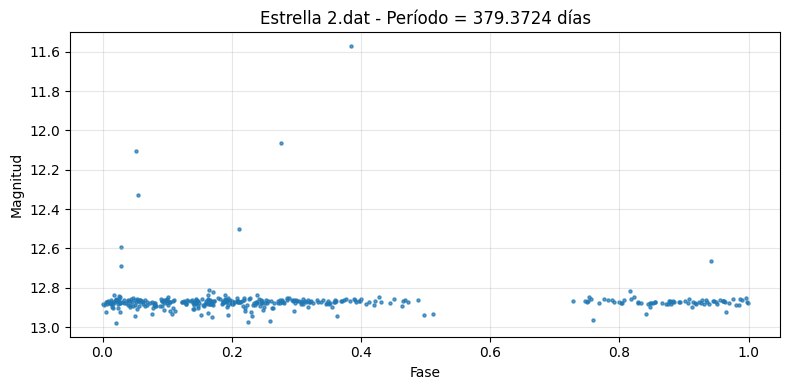

5000it [00:04, 1024.04it/s]████      | 2/5 [00:09<00:14,  4.78s/it]


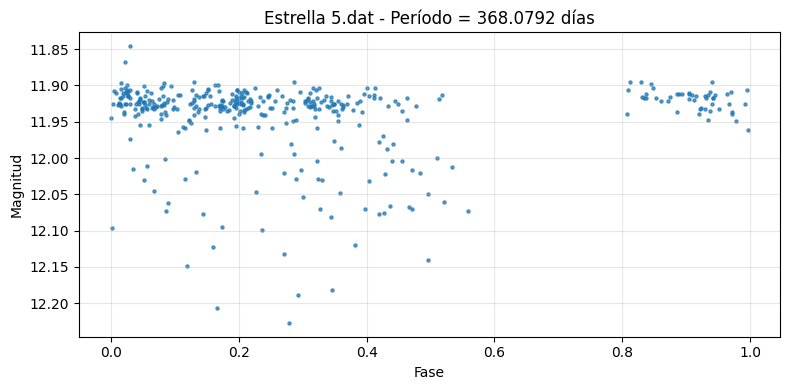

5000it [00:04, 1114.36it/s]██████    | 3/5 [00:14<00:09,  4.97s/it]


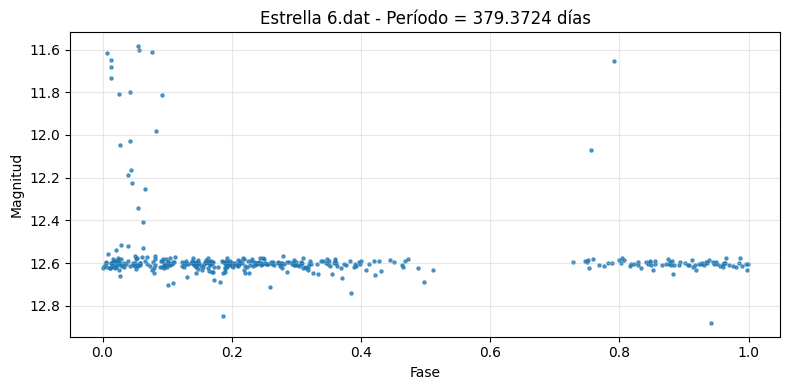

5000it [00:04, 1080.93it/s]████████  | 4/5 [00:19<00:04,  4.89s/it]


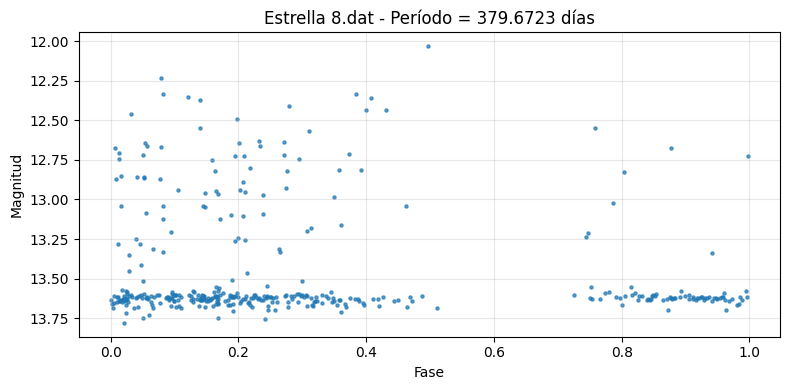

Procesando estrellas: 100%|██████████| 5/5 [00:24<00:00,  4.88s/it]


RESUMEN DE RESULTADOS
1: Período = 378.872735 días, Entropía = 1.5348, Puntos = 382
2: Período = 379.372434 días, Entropía = 1.0869, Puntos = 382
5: Período = 368.079216 días, Entropía = 1.7021, Puntos = 382
6: Período = 379.372434 días, Entropía = 1.2863, Puntos = 382
8: Período = 379.672254 días, Entropía = 1.7258, Puntos = 382

Resultados guardados en 'resultados_periodos.csv'


In [3]:
# EJECUCIÓN
if __name__ == "__main__":
    # Procesar primeros 5 archivos
    resultados = procesar_archivos_bul5I(
        carpeta="data/bul5I",
        N=5,  # Número de archivos a leer
        p0=0.4,
        p1=500,
        p_num=5000,  # Menos puntos para pruebas rápidas
        plot_individual=True  # Muestra cada curva de luz
    )
    
    # Guardar resultados a CSV
    resultados.to_csv("resultados_periodos.csv", index=False)
    print(f"\nResultados guardados en 'resultados_periodos.csv'")

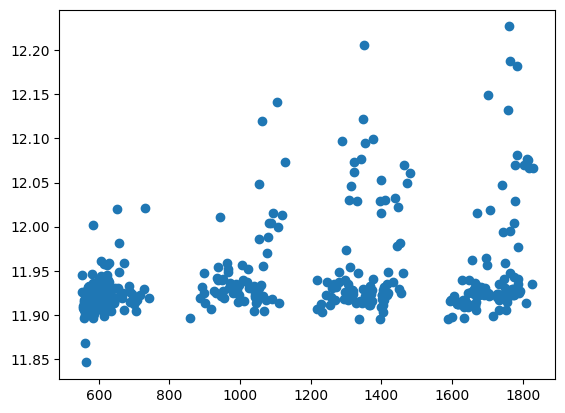

In [ ]:
data = pd.read_csv("data/bul5I/6.dat", sep=" ", lineterminator="\n",names=("t","u","inc_u"))
t = data["t"]
u = data["u"]

plt.scatter(t,u)